# Recommendation Engine / System
## Proyecto: Recomendador de Repositorios de Github
### Usaremos Collaborative Filtering
Artículo completo en https://www.aprendemachinelearning.com/sistemas-de-recomendacion/

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import sklearn

In [2]:
df_users = pd.read_csv("https://github.com/palasatenea66/DATASETS/raw/main/users.csv")
df_repos = pd.read_csv("https://github.com/palasatenea66/DATASETS/raw/main/repos.csv")
df_ratings = pd.read_csv("https://github.com/palasatenea66/DATASETS/raw/main/ratings.csv")

In [3]:
df_users

,userId,username,name
0,1,iris9112,Isabel Ruiz Buriticá
1,2,dianaclarke,Diana
2,3,nateprewitt,Nate Prewitt
3,4,oldani,Ordanis Sanchez
4,5,waflessnet,waflessnet
5,6,luisbalru,Luis Balderas Ruiz
6,7,elswork,elswork
7,8,l3s777,l3s777
8,9,camiloyate09,Camilo Yate
9,10,josmig,José Miguel Pantigoso


In [4]:
df_repos

,repoId,title,categories,stars
0,1,airbnb / javascript,completar,NaN
1,2,kamranahmedse / developer-roadmap,Roadmap to becoming a web developer in 2019,85800.0
2,3,microsoft / vscode,Visual Studio Code,80855.0
3,4,torvalds / linux,Linux kernel source tree,78761.0
4,5,ytdl-org / youtube-dl,Command-line program to download videos from Y...,53909.0
...,...,...,...,...
162,163,OmkarPathak / pygorithm,A Python module for learning all major algorithms,3743.0
163,164,MaximAbramchuck / awesome-interview-questions,A curated awesome list of lists of interview q...,28689.0
164,165,nodejs / node,Node.js JavaScript runtime,63397.0
165,166,OWASP / CheatSheetSeries,The OWASP Cheat Sheet Series was created to pr...,7793.0


In [5]:
df_ratings

,userId,repoId,rating
0,1,1,2
1,1,2,3
2,1,3,4
3,1,4,5
4,1,5,3
...,...,...,...
319,30,118,3
320,30,156,2
321,30,162,2
322,30,125,2


In [11]:
df_ratings[df_ratings['repoId']==4]

,userId,repoId,rating
3,1,4,5
56,5,4,5
95,10,4,5
219,21,4,5
306,30,4,5


In [12]:
n_users = df_ratings.userId.unique().shape[0]
n_items = df_ratings.repoId.unique().shape[0]
print (str(n_users) + ' users')
print (str(n_items) + ' items')

30 users
167 items


In [17]:
df_ratings['rating'].unique()

array([2, 3, 4, 5, 1, 8, 6, 7])

(array([94., 62., 66., 28., 40., 12., 14.,  8.]),
 array([1.   , 1.875, 2.75 , 3.625, 4.5  , 5.375, 6.25 , 7.125, 8.   ]),
 <BarContainer object of 8 artists>)

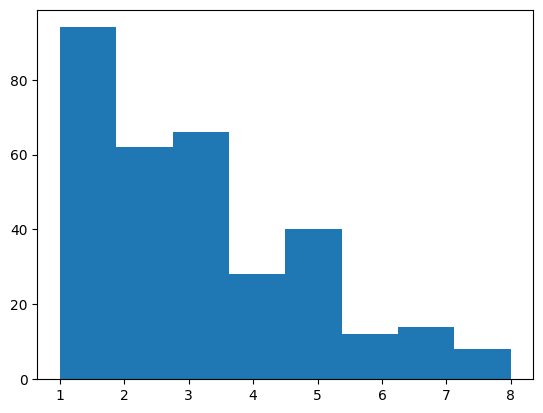

In [13]:
plt.hist(df_ratings.rating,bins=8)

In [14]:
df_ratings.groupby(["rating"])["userId"].count()

,userId
rating,
1,94
2,62
3,66
4,28
5,40
6,12
7,14
8,8


In [15]:
df_ratings[df_ratings['rating']==7]

,userId,repoId,rating
68,6,62,7
69,7,62,7
70,7,63,7
79,8,63,7
96,10,62,7
104,11,63,7
105,11,62,7
128,14,62,7
137,15,62,7
182,18,62,7


(array([94., 31., 22.,  7.,  8.,  2.,  2.,  1.]),
 array([1.   , 1.875, 2.75 , 3.625, 4.5  , 5.375, 6.25 , 7.125, 8.   ]),
 <BarContainer object of 8 artists>)

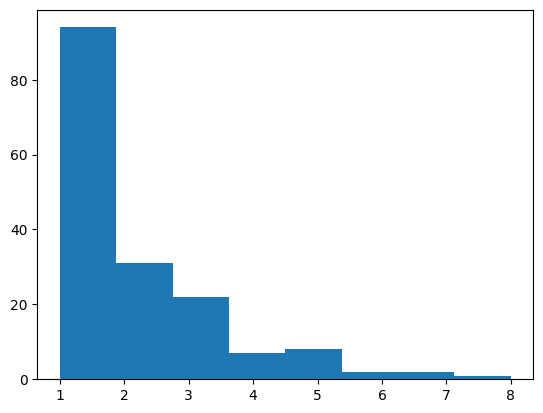

In [16]:
plt.hist(df_ratings.groupby(["repoId"])["repoId"].count(),bins=8)

# Método 1: User-Based

In [18]:
df_matrix = pd.pivot_table(df_ratings, values='rating', index='userId', columns='repoId').fillna(0)
df_matrix

repoId,1,2,3,4,5,6,7,8,9,10,...,158,159,160,161,162,163,164,165,166,167
userId,,,,,,,,,,,,,,,,,,,,,
1,2.0,3.0,4.0,5.0,3.0,1.0,5.0,1.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
ratings = df_matrix.values
ratings.shape

(30, 167)

In [20]:
ratings = df_matrix.values
sparsity = float(len(ratings.nonzero()[0]))
sparsity /= (ratings.shape[0] * ratings.shape[1])
sparsity *= 100
print(f'Sparsity: {round(sparsity,2)}%')

Sparsity: 6.43%


In [21]:
float(len(ratings.nonzero()[0]))

322.0

In [22]:
ratings_train, ratings_test = train_test_split(ratings, test_size = 0.2, shuffle=False, random_state=42)

In [23]:
ratings_train.shape

(24, 167)

In [24]:
ratings_test.shape

(6, 167)

<ul>
<li>Matriz de similitud entre los usuarios (distancia del coseno -vectores-).</li>
<li>Predecir la valoración desconocida de un ítem i para un usuario activo u basandonos en la suma ponderada de todas las valoraciones del resto de usuarios para dicho ítem.</li>
<li>Recomendaremos los nuevos ítems a los usuarios según lo establecido en los pasos anteriores.</li>
</ul>

In [25]:
sim_matrix = 1 - sklearn.metrics.pairwise.cosine_distances(ratings)

In [26]:
sim_matrix.shape

(30, 30)

In [27]:
sim_matrix

array([[1.        , 0.44336599, 0.49830328, 0.36802007, 0.24677596,
        0.        , 0.        , 0.11574818, 0.09821559, 0.12887454,
        0.        , 0.2648261 , 0.        , 0.06187576, 0.16527235,
        0.        , 0.2564571 , 0.        , 0.18734552, 0.09516725,
        0.48917543, 0.17318984, 0.03772565, 0.49609349, 0.15436059,
        0.30893011, 0.10339378, 0.        , 0.16295172, 0.51682627],
       [0.44336599, 1.        , 0.73881135, 0.49750116, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.36858386, 0.        , 0.        , 0.73553501, 0.        ,
        0.66558424, 0.        , 0.        , 0.        , 0.41674581],
       [0.49830328, 0.73881135, 1.        , 0.535097  , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.

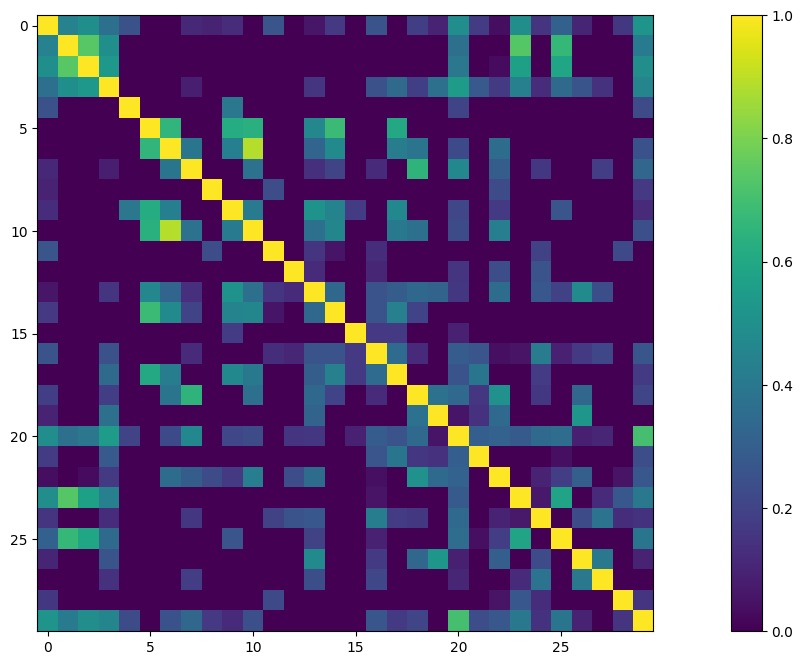

In [28]:
plt.rcParams['figure.figsize'] = (20.0, 8.0)
plt.imshow(sim_matrix);
plt.colorbar()
plt.show()

In [29]:
#separar las filas y columnas de train y test
sim_matrix_train = sim_matrix[0:24,0:24]
sim_matrix_test = sim_matrix[24:30,24:30]
print(sim_matrix_train.shape)
print(sim_matrix_test.shape)

(24, 24)
(6, 6)


## Predicciones (las recomendaciones!)

In [30]:
users_predictions = sim_matrix_train.dot(ratings_train) / np.array([np.abs(sim_matrix_train).sum(axis=1)]).T

In [31]:
users_predictions.shape

(24, 167)

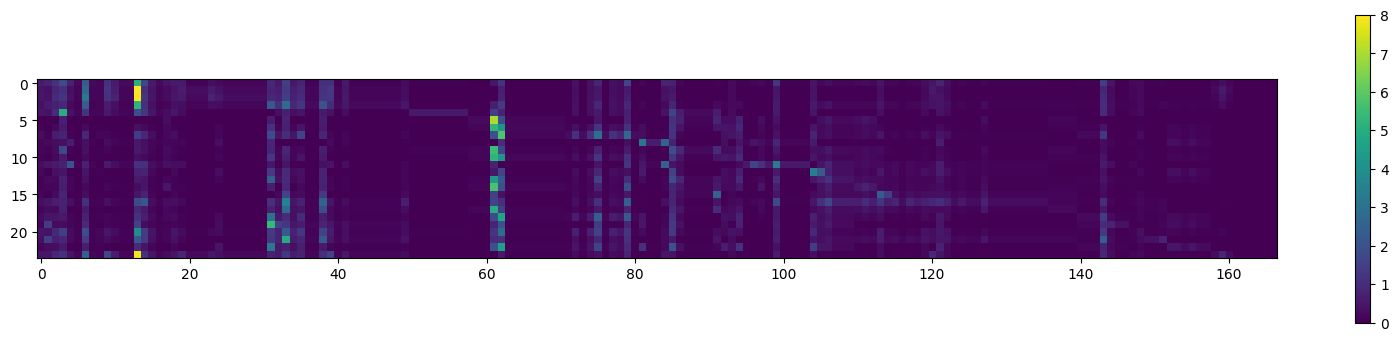

In [32]:
plt.rcParams['figure.figsize'] = (20.0, 4.0)
plt.imshow(users_predictions);
plt.colorbar()
plt.show()

### Veamos un ejemplo

In [33]:
USUARIO_EJEMPLO = 'jbagnato' # debe existir en nuestro dataset de train!
data = df_users[df_users['username'] == USUARIO_EJEMPLO]
usuario_ver = data.iloc[0]['userId'] -1 # resta 1 para obtener el index de pandas
user0=users_predictions.argsort()[usuario_ver]

# Veamos los tres recomendados con mayor puntaje en la predic para este usuario
for i, aRepo in enumerate(user0[-3:]):
    selRepo = df_repos[df_repos['repoId']==(aRepo+1)]
    print(selRepo['title'] , 'puntaje:', users_predictions[usuario_ver][aRepo])

4    ytdl-org / youtube-dl
Name: title, dtype: object puntaje: 2.061791042203265
84    dipanjanS / practical-machine-learning-with-py...
Name: title, dtype: object puntaje: 2.4496166855518746
99    abhat222 / Data-Science--Cheat-Sheet
Name: title, dtype: object puntaje: 3.362878201910944


## Medir el Error

In [34]:
def get_mse(preds, actuals):
    if preds.shape[1] != actuals.shape[1]:
        actuals = actuals.T
    preds = preds[actuals.nonzero()].flatten()
    actuals = actuals[actuals.nonzero()].flatten()
    return mean_squared_error(preds, actuals)


In [35]:
get_mse(users_predictions, ratings_train)

3.3906497514974663

In [36]:
# Realizo las predicciones para el test set
users_predictions_test = sim_matrix.dot(ratings) / np.array([np.abs(sim_matrix).sum(axis=1)]).T
users_predictions_test = users_predictions_test[24:30,:]

get_mse(users_predictions_test, ratings_test)

4.722040854666231

# Método 2: Usando Nearest Neighbors

In [37]:
k = 8
neighbors = NearestNeighbors(n_neighbors=k, metric='cosine')
neighbors.fit(ratings_train)

NearestNeighbors(metric='cosine', n_neighbors=8)

In [38]:
top_k_distances, top_k_users = neighbors.kneighbors(ratings_train, return_distance=True)
top_k_distances.shape

(24, 8)

In [39]:
top_k_distances[usuario_ver]

array([0.        , 0.7351739 , 0.76208452, 0.8501134 , 0.86746954,
       0.94477898, 1.        , 1.        ])

In [40]:
top_k_users.shape

(24, 8)

In [41]:
res = top_k_users[usuario_ver]
res

array([11,  0,  8, 13, 16, 14, 18, 22])

In [42]:
for a_index in res:
    print(df_users[df_users['userId'] == (a_index+1)])

    userId  username                  name
11      12  jbagnato  Juan Ignacio Bagnato
   userId  username                  name
0       1  iris9112  Isabel Ruiz Buriticá
   userId      username         name
8       9  camiloyate09  Camilo Yate
    userId   username    name
13      14  aguadotzn  Adrián
    userId     username                    name
16      17  carlosevi94  Carlos Sevilla Barceló
    userId       username           name
14      15  sjvasconcello  sjvasconcello
    userId     username          name
18      19  marisbotero  Maris Botero
    userId  username        name
22      23  kevin11h  Kevin Hung


In [43]:
users_predicts_k = np.zeros(ratings_train.shape)

for i in range(ratings_train.shape[0]):# para cada usuario del conjunto de entrenamiento
    users_predicts_k[i,:] = top_k_distances[i].T.dot(ratings_train[top_k_users][i]) / np.array([np.abs(top_k_distances[i].T).sum(axis=0)]).T

In [44]:
users_predicts_k.shape

(24, 167)

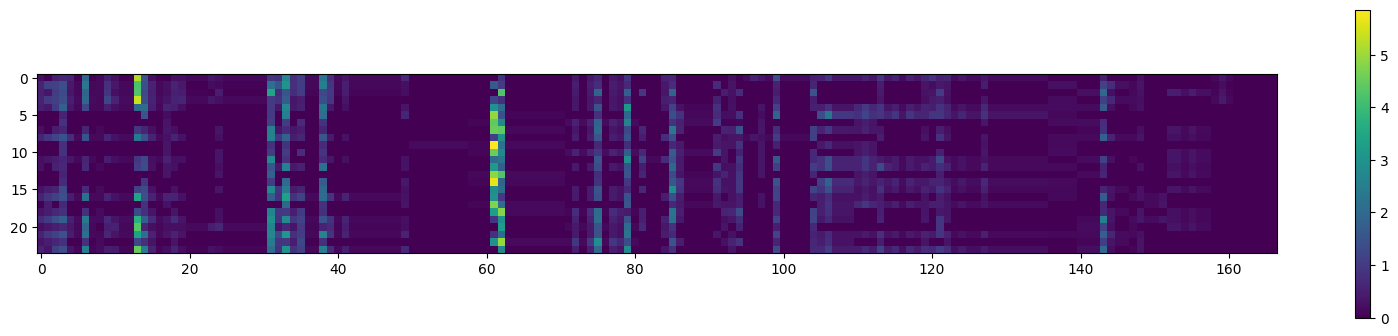

In [45]:
plt.imshow(users_predicts_k);
plt.colorbar()
plt.show()

In [46]:
user0=users_predicts_k.argsort()[usuario_ver][-4:]
# los tres con mayor puntaje en la predic para este usuario
# agrego 4 puesto que uno es mi propio repositorio
for aRepo in user0:
    selRepo = df_repos[df_repos['repoId'] == (aRepo+1)]
    print(selRepo['title'], 'puntaje:', users_predicts_k[usuario_ver][aRepo])

61    jbagnato / machine-learning
Name: title, dtype: object puntaje: 2.0397761420377654
62    tensorflow / tensorflow
Name: title, dtype: object puntaje: 2.2728673580549694
31    freeCodeCamp / freeCodeCamp
Name: title, dtype: object puntaje: 2.7762555883083695
79    jakevdp / PythonDataScienceHandbook
Name: title, dtype: object puntaje: 2.879578790241746


In [47]:
get_mse(users_predicts_k, ratings_train)

5.7944864954921425

In [48]:
get_mse(users_predicts_k, ratings_test)

10.727470808481653

# Método 3: Collaborative Filtering Basado en Items

In [49]:
#basado en items
n_repos = ratings_train.shape[1]
n_repos

167

In [50]:
neighbors = NearestNeighbors(n_neighbors=n_repos, metric='cosine')
neighbors.fit(ratings_train.T)

NearestNeighbors(metric='cosine', n_neighbors=167)

In [51]:
top_k_distances, top_k_items = neighbors.kneighbors(ratings_train.T, return_distance=True)
top_k_distances.shape

(167, 167)

In [53]:
top_k_items.shape

(167, 167)

In [52]:
top_k_items

array([[  0,  15,  18, ...,  60,  58, 166],
       [  1, 144, 145, ...,  73,  67, 166],
       [  0,  15,  18, ...,  60,  58, 166],
       ...,
       [  0, 106, 107, ...,  59,  61, 166],
       [  0, 106, 107, ...,  59,  61, 166],
       [  0, 106, 107, ...,  59,  61, 166]])

In [54]:
data = df_repos[df_repos['title'] == 'jbagnato / machine-learning']
repo_ver = data.iloc[0]['repoId'] -1
repo_ver

61

In [55]:
df_repos[df_repos['repoId'].isin([repo_ver+1])]

,repoId,title,categories,stars
61,62,jbagnato / machine-learning,"Código Python, Jupyter Notebooks, archivos csv...",48.0


In [56]:
item_preds = ratings_train.dot(top_k_distances) / np.array([np.abs(top_k_distances).sum(axis=1)])

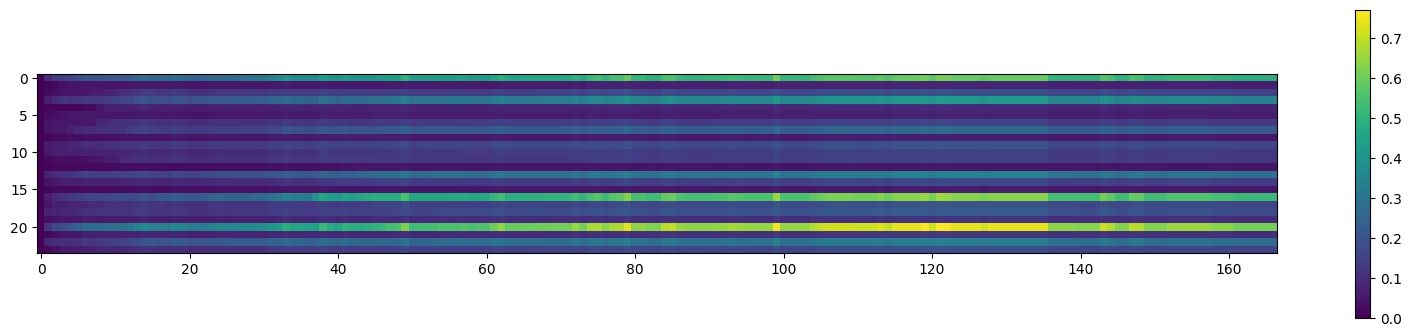

In [57]:
plt.imshow(item_preds);
plt.colorbar()
plt.show()

In [58]:
user0=item_preds.argsort()[usuario_ver]
user0

# los tres con mayor puntaje en la predic para este usuario
for aRepo in user0[-3:]:
    selRepo = df_repos[df_repos['repoId']==(aRepo+1)]
    print(selRepo['title'], 'puntaje:', item_preds[usuario_ver][aRepo])

119    donnemartin / data-science-ipython-notebooks
Name: title, dtype: object puntaje: 0.15701711431739965
122    start
Name: title, dtype: object puntaje: 0.15701711431739965
121    datasciencemasters / go
Name: title, dtype: object puntaje: 0.1587462822190084


In [59]:
get_mse(item_preds, ratings_train)

10.358710723721423

In [60]:
get_mse(item_preds, ratings_test)

14.05563947597318

# Método 4: recomendación por Correlación

In [61]:
average_rating = pd.DataFrame(df_ratings.groupby('repoId')['rating'].mean())
average_rating['ratingCount'] = pd.DataFrame(df_ratings.groupby('repoId')['rating'].count())
average_rating.sort_values('ratingCount', ascending=False).head()

mi_repo_ratings = df_matrix[62]
similar_to_mine = df_matrix.corrwith(mi_repo_ratings)
corr_mine = pd.DataFrame(similar_to_mine, columns=['pearsonR'])
corr_mine.dropna(inplace=True)
corr_summary = corr_mine.join(average_rating['rating'])
corr_summary[corr_summary['rating']>=1].sort_values('pearsonR', ascending=False).head(10)

,pearsonR,rating
repoId,,
62,1.000000,7.0
87,0.341515,3.0
92,0.341515,3.0
95,0.341515,3.0
139,0.336601,1.0
138,0.336601,1.0
137,0.336601,1.0
140,0.336601,1.0
88,0.336601,1.0


In [62]:
# Veamos uno de los recomendados
df_repos[df_repos['repoId'] == 92]

,repoId,title,categories,stars
91,92,joanby / python-ml-course,Curso de Introducción a Machine Learning con P...,156.0


# Método 5: Repo más popular -sin collaborative filtering-

Esta es la manera básica y sin uso de machine learning de ofrecer recomendaciones. <br>
estas no serán personalizadas, serán iguales para cualquier usuario

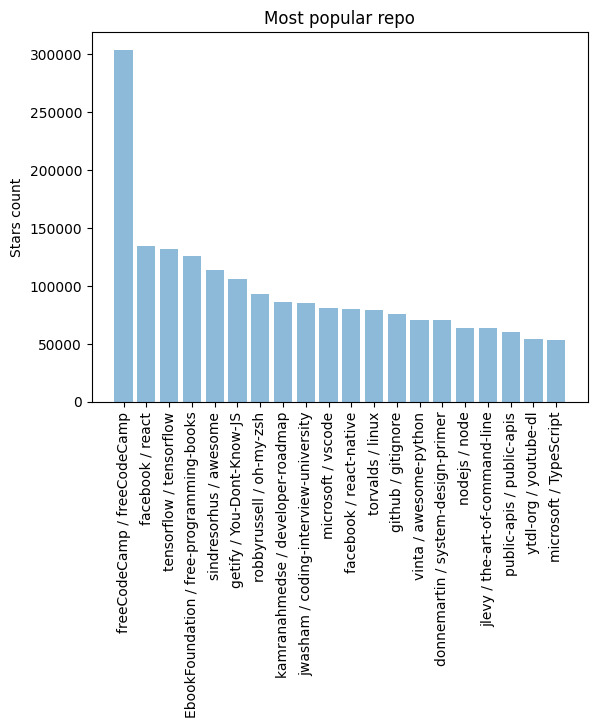

In [64]:
popular_repo = df_repos[['title','stars']].groupby('stars').sum().reset_index()
popular_repo_top_20 = popular_repo.sort_values('stars', ascending=False).head(n=20)

plt.rcdefaults()

objects = (list(popular_repo_top_20['title']))
y_pos = np.arange(len(objects))
performance = list(popular_repo_top_20['stars'])

plt.bar(y_pos, performance, align='center', alpha=0.5)
plt.xticks(y_pos, objects, rotation='vertical')
plt.ylabel('Stars count')
plt.title('Most popular repo')

plt.show()